In [1]:
import sys
import os

sys.argv = ['']
sys.path.append("..")

import numpy as np
import random
from collections import deque
from typing import List, Tuple, Any, Optional
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
from rl_algorithms.utils.agent import Agent
from rl_algorithms.utils.utils import state_to_idx_tensor, idx_tensor_to_state, calculate_distance
from rl_algorithms.utils.replaybuffer import ReplayBuffer
from rl_algorithms.net.qnet import Qnet
from env.env import Env


import torch
import torch.nn as nn
import torch.nn.functional as F


import torch
import torch.nn as nn

In [2]:
class DQN(Agent):
    def __init__(self, env, agent_id=None,
                 lr=0.001, gamma=0.99, iteration=10,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 num_episodes=10, episode_length=400000,
                 batch_size=64, mini_batch_size=32,
                 hidden_dim=128, update_freq=100, device=torch.device("cuda")):
        super().__init__(env=env,
                         lr=lr, gamma=gamma,
                         epsilon=epsilon, epsilon_min=epsilon_min,
                         epsilon_decay=epsilon_decay, num_episodes=num_episodes, episode_length=episode_length)

        self.agent_id = agent_id
        self.iteration = iteration

        # 初始化经验回放缓冲区
        self.buffer = ReplayBuffer(
            episode_length * num_episodes * env.num_agents)
        self.batch_size = batch_size
        self.mini_batch_size = mini_batch_size

        self.hidden_dim = hidden_dim

        # 初始化Q网络和目标Q网络
        state_num = env.state_num  # 总状态数
        self.qnet = Qnet(state_num=state_num, embedding_dim=64, hidden_dim=hidden_dim,
                         action_dim=env.num_actions, x_dim=env.x_dim, y_dim=env.y_dim)
        self.target_qnet = Qnet(state_num=state_num, embedding_dim=64, hidden_dim=hidden_dim,
                                action_dim=env.num_actions, x_dim=env.x_dim, y_dim=env.y_dim)
        self.target_qnet.load_state_dict(self.qnet.state_dict())
        self.target_qnet.eval()

        # 初始化优化器和损失函数
        self.optimizer = optim.Adam(self.qnet.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

        # 初始化设备
        self.device = device
        self.qnet.to(self.device)
        self.target_qnet.to(self.device)

        self.update_freq = update_freq

    def take_action(self, state, training=True):
        """
        选择动作
        :param state: 状态
        :param agent_id: 机器人编号
        :param training: 是否处于训练模式
        :return: action索引（int）
        """
        if self.agent_id is None:
            self.agent_id = 0
        target = self.env.target_states[self.agent_id]
        if state == target:
            # 到达目标后保持不动，返回停留动作的索引
            return 0  # 默认返回第0个动作
        else:
            # 将 (x, y) 转换为 state_idx: state_idx = x * y_dim + y
            state_idx_tensor = state_to_idx_tensor(
                state, self.env.y_dim, self.device)
            target_idx_tensor = state_to_idx_tensor(
                target, self.env.y_dim, self.device)

            with torch.no_grad():
                action_values = self.qnet(state_idx_tensor, target_idx_tensor)

            # 获取最优动作
            optimal_action = action_values.argmax(dim=1).item()

            if training:
                # 概率分配：最优动作概率最大，其他动作概率相同
                # 最优动作概率：1 - epsilon + epsilon/num_actions
                # 其他动作概率：epsilon/num_actions
                num_actions = self.env.num_actions
                probs = torch.full(
                    (num_actions,), self.epsilon / num_actions, device=self.device)
                probs[optimal_action] = 1 - self.epsilon + \
                    self.epsilon / num_actions

                # 根据概率分布采样动作
                dist = torch.distributions.Categorical(probs=probs)
                action = dist.sample().item()
                return action
            else:
                # 测试模式：直接返回最优动作
                return optimal_action

    def update(self):
        batch = self.buffer.sample(self.mini_batch_size)

        states = np.array([b[0] for b in batch])
        actions = np.array([b[1] for b in batch])
        rewards = np.array([b[2] for b in batch], dtype=np.float32)
        next_states = np.array([b[3] for b in batch])
        dones = np.array([b[4] for b in batch], dtype=np.float32)

        state_idx = state_to_idx_tensor(states, self.env.y_dim, self.device)
        next_state_idx = state_to_idx_tensor(
            next_states, self.env.y_dim, self.device)

        action_tensor = torch.tensor(
            actions, dtype=torch.long, device=self.device)
        reward_tensor = torch.tensor(rewards, device=self.device)
        dones_tensor = torch.tensor(
            dones, dtype=torch.float32, device=self.device)

        # 将 target 转换为 tensor，并扩展到 batch 大小
        target = self.env.target_states[self.agent_id]
        target_idx_single = state_to_idx_tensor(
            target, self.env.y_dim, self.device)
        target_idx = target_idx_single.repeat(len(batch))

        q = self.qnet(state_idx, target_idx)
        q = q.gather(1, action_tensor.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q = self.target_qnet(next_state_idx, target_idx)
            max_next_q = next_q.max(dim=1)[0]
            td_target = reward_tensor + self.gamma * \
                max_next_q * (1 - dones_tensor)

        loss = self.loss_fn(q, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_qnet(self):
        """同步目标Q网络参数"""
        self.target_qnet.load_state_dict(self.qnet.state_dict())

    def save(self, path: str):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save({
            "qnet": self.qnet.state_dict(),
            "target_qnet": self.target_qnet.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "epsilon": self.epsilon,
        }, path)
        print(f"模型已保存到: {path}")

    def load(self, path: str):
        if not os.path.isfile(path):
            raise FileNotFoundError(f"未找到模型文件: {path}")
        checkpoint = torch.load(path, map_location=self.device)
        self.qnet.load_state_dict(checkpoint["qnet"])
        self.target_qnet.load_state_dict(
            checkpoint.get("target_qnet", checkpoint["qnet"]))
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.epsilon = checkpoint.get("epsilon", self.epsilon)

In [3]:
def train_dqn(env, dqn):
    print(f"Begin to train DQN, iteration: {dqn.iteration}")
    epsilon = dqn.epsilon
    return_list = []
    for i in range(dqn.iteration):
        dqn.epsilon = epsilon
        # 使用tqdm创建进度条
        pbar = tqdm(range(1, dqn.num_episodes + 1),
                    desc=f"Iteration({i+1}) progress".format(i+1), unit="episode")
        for ep in pbar:
            states, _ = env.reset()
            state = states[dqn.agent_id]
            ep_return = 0
            for t in range(dqn.episode_length):
                action_idx = dqn.take_action(state, training=True)
                action = env.action_space[action_idx]
                next_state, reward, done, _ = env.step(action)
                ep_return += reward
                dqn.buffer.add(state, action_idx, reward, next_state, done)
                if len(dqn.buffer) >= dqn.mini_batch_size:
                    dqn.update()
                state = next_state
                if t % dqn.update_freq == 0:
                    dqn.update_target_qnet()
                if done:
                    break
            return_list.append(ep_return)
            # epsilon **按 episode 衰减**
            dqn.epsilon = max(dqn.epsilon_min, dqn.epsilon * dqn.epsilon_decay)
            pbar.set_postfix({
                'Episode': ep,
                'Return': f'{ep_return:.2f}',
                'Epsilon': f'{dqn.epsilon:.3f}'
            })
    return dqn, return_list

In [4]:
env = Env()
dqn =DQN(
            env,
            agent_id=0,
            lr=1e-3,
            gamma=0.99,
            iteration=5,
            epsilon=0.8,
            epsilon_decay=0.9,   # 按 episode
            epsilon_min=0.1,
            num_episodes=50,
            episode_length=35000,
            mini_batch_size=64,
            update_freq=10,
            device=torch.device("cpu")
        )
print(dqn.device)
dqn, return_list = train_dqn(env, dqn)

cpu
Begin to train DQN, iteration: 5


Iteration(5) progress: 100%|██████████| 50/50 [00:07<00:00,  6.57episode/s, Episode=50, Return=9.00, Epsilon=0.100] 


In [5]:
dqn.save("../models/dqn_model_test.pth")

模型已保存到: ../models/dqn_model_test.pth


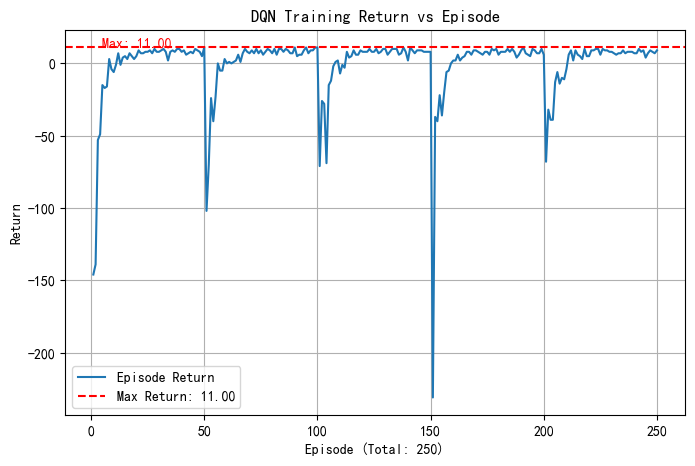

In [6]:
# plot
import matplotlib.pyplot as plt
# 按照 return_list 绘制曲线
total_episodes = dqn.iteration * dqn.num_episodes
max_return = max(return_list)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(return_list)+1), return_list, label="Episode Return")
plt.axhline(y=max_return, color='r', linestyle='--', label=f"Max Return: {max_return:.2f}")
plt.xlabel(f'Episode (Total: {len(return_list)})')
plt.ylabel('Return')
plt.title('DQN Training Return vs Episode')
plt.grid(True)
plt.legend()
# 在图表上标注 max_return 数值
plt.text(len(return_list) * 0.02, max_return * 1.02, f'Max: {max_return:.2f}', 
         fontsize=10, color='r', fontweight='bold')
plt.show()

